In [1]:
from google.colab import files

uploaded = files.upload()

Saving smart_traffic_ml_cleaned.csv to smart_traffic_ml_cleaned.csv


# Import Required Libraries


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [75]:
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3


# Load Dataset

In [76]:
df = pd.read_csv("smart_traffic_ml_cleaned.csv")

# Understand the Dataset

In [77]:
df.shape

(40575, 14)

In [78]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day,day_of_week,month,year,is_weekend
0,NaN,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,2,1,10,2012,0
1,NaN,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,2,1,10,2012,0
2,NaN,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,2,1,10,2012,0
3,NaN,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,2,1,10,2012,0
4,NaN,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,2,1,10,2012,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40575 entries, 0 to 40574
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   holiday         53 non-null     object 
 1   temp            40575 non-null  float64
 2   rain_1h         40575 non-null  float64
 3   snow_1h         40575 non-null  float64
 4   clouds_all      40575 non-null  int64  
 5   weather_main    40575 non-null  object 
 6   date_time       40575 non-null  object 
 7   traffic_volume  40575 non-null  int64  
 8   hour            40575 non-null  int64  
 9   day             40575 non-null  int64  
 10  day_of_week     40575 non-null  int64  
 11  month           40575 non-null  int64  
 12  year            40575 non-null  int64  
 13  is_weekend      40575 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 4.3+ MB


In [80]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day,day_of_week,month,year,is_weekend
count,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000
mean,281.316746,0.318647,0.000117,44.201528,3290.650474,11.514750,15.672754,3.006778,6.489045,2015.479729,0.285792
std,13.816567,48.812641,0.005676,38.683697,1984.772909,6.949889,8.763954,1.998947,3.373618,1.888817,0.451796
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2012.000000,0.000000
25%,271.840000,0.000000,0.000000,1.000000,1248.500000,5.000000,8.000000,1.000000,4.000000,2014.000000,0.000000
50%,282.860000,0.000000,0.000000,40.000000,3427.000000,12.000000,16.000000,3.000000,7.000000,2016.000000,0.000000
75%,292.280000,0.000000,0.000000,90.000000,4952.000000,18.000000,23.000000,5.000000,9.000000,2017.000000,1.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000,23.000000,31.000000,6.000000,12.000000,2018.000000,1.000000


# Data Preprocessing

In [81]:
df.isnull().sum()

,0
holiday,40522
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
date_time,0
traffic_volume,0
hour,0
day,0


In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df['date_time'].duplicated().sum()

np.int64(0)

In [84]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [85]:
df = df.sort_values('date_time').reset_index(drop=True)

In [86]:
df[['date_time', 'traffic_volume']].head(10)

,date_time,traffic_volume
0,2012-10-02 09:00:00,5545
1,2012-10-02 10:00:00,4516
2,2012-10-02 11:00:00,4767
3,2012-10-02 12:00:00,5026
4,2012-10-02 13:00:00,4918
5,2012-10-02 14:00:00,5181
6,2012-10-02 15:00:00,5584
7,2012-10-02 16:00:00,6015
8,2012-10-02 17:00:00,5791
9,2012-10-02 18:00:00,4770


# Feature Engineering

In [87]:
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [88]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day,day_of_week,month,year,is_weekend
0,NaN,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,2,1,10,2012,0
1,NaN,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,2,1,10,2012,0
2,NaN,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,2,1,10,2012,0
3,NaN,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,2,1,10,2012,0
4,NaN,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,2,1,10,2012,0


In [89]:
df['holiday'].isnull().sum()

np.int64(40522)

In [90]:
df['holiday'].value_counts(dropna=False)

,count
holiday,
NaN,40522
Columbus Day,5
Veterans Day,5
Thanksgiving Day,5
Christmas Day,5
New Years Day,5
Washingtons Birthday,5
Memorial Day,5
Independence Day,5


In [91]:
df['holiday'] = df['holiday'].fillna('No Holiday')

In [92]:
df['holiday'].value_counts()

,count
holiday,
No Holiday,40522
Columbus Day,5
Veterans Day,5
Thanksgiving Day,5
Christmas Day,5
New Years Day,5
Washingtons Birthday,5
Memorial Day,5
Independence Day,5


In [93]:
df['is_holiday'] = (df['holiday'] != 'No Holiday').astype(int)

In [94]:
df['is_holiday'].value_counts()

,count
is_holiday,
0,40522
1,53


In [95]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'date_time', 'traffic_volume', 'hour', 'day', 'day_of_week', 'month',
       'year', 'is_weekend', 'is_holiday'],
      dtype='object')

In [96]:
df['weather_main'].value_counts()

,count
weather_main,
Clouds,15124
Clear,13365
Rain,4342
Mist,3277
Snow,2161
Haze,812
Drizzle,689
Thunderstorm,499
Fog,293


In [97]:
df['weather_main'].nunique()

11

In [98]:
weather_encoded = pd.get_dummies(
    df['weather_main'],
    prefix='weather'
)

weather_encoded.head()

,weather_Clear,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,False,True,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False


In [99]:
weather_encoded = weather_encoded.astype(int)

In [100]:
weather_encoded.head()

,weather_Clear,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,0,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0


In [101]:
df = pd.concat([df, weather_encoded], axis=1)

In [102]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day,...,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,No Holiday,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,2,...,1,0,0,0,0,0,0,0,0,0
1,No Holiday,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,2,...,1,0,0,0,0,0,0,0,0,0
2,No Holiday,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,2,...,1,0,0,0,0,0,0,0,0,0
3,No Holiday,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,2,...,1,0,0,0,0,0,0,0,0,0
4,No Holiday,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,2,...,1,0,0,0,0,0,0,0,0,0


In [103]:
df.shape

(40575, 26)

In [104]:
df = df.drop(columns=['holiday', 'weather_main'])

In [105]:
df.columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'date_time',
       'traffic_volume', 'hour', 'day', 'day_of_week', 'month', 'year',
       'is_weekend', 'is_holiday', 'weather_Clear', 'weather_Clouds',
       'weather_Drizzle', 'weather_Fog', 'weather_Haze', 'weather_Mist',
       'weather_Rain', 'weather_Smoke', 'weather_Snow', 'weather_Squall',
       'weather_Thunderstorm'],
      dtype='object')

# Exploratory Data Analysis

In [106]:
df[['date_time', 'traffic_volume']].head()

,date_time,traffic_volume
0,2012-10-02 09:00:00,5545
1,2012-10-02 10:00:00,4516
2,2012-10-02 11:00:00,4767
3,2012-10-02 12:00:00,5026
4,2012-10-02 13:00:00,4918


In [107]:
df[['date_time', 'traffic_volume']].tail()

,date_time,traffic_volume
40570,2018-09-30 19:00:00,3543
40571,2018-09-30 20:00:00,2781
40572,2018-09-30 21:00:00,2159
40573,2018-09-30 22:00:00,1450
40574,2018-09-30 23:00:00,954


In [108]:
time_diff = df['date_time'].diff()

time_diff.value_counts().head(10)

,count
date_time,
0 days 01:00:00,37986
0 days 02:00:00,2192
0 days 03:00:00,201
0 days 04:00:00,59
0 days 05:00:00,33
0 days 06:00:00,17
0 days 08:00:00,13
0 days 10:00:00,13
0 days 09:00:00,12


In [109]:
df['new_segment'] = (
    df['date_time'].diff() != pd.Timedelta(hours=1)
).astype(int)

In [110]:
df['segment_id'] = df['new_segment'].cumsum()

In [111]:
df['segment_id'].nunique()

2589

In [112]:
segment_lengths = df.groupby('segment_id').size()
segment_lengths.describe()

,0
count,2589.000000
mean,15.672074
std,88.486590
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,1915.000000


In [113]:
(segment_lengths >= 25).sum()

np.int64(173)

In [114]:
print("Start:", df['date_time'].min())
print("End:", df['date_time'].max())

Start: 2012-10-02 09:00:00
End: 2018-09-30 23:00:00


In [115]:
train_end = df['date_time'].quantile(0.70)
val_end = df['date_time'].quantile(0.85)

print("Training ends:", train_end)
print("Validation ends:", val_end)

Training ends: 2017-05-10 04:48:00
Validation ends: 2018-01-19 14:54:00


In [116]:
df['traffic_volume'].describe()

,traffic_volume
count,40575.000000
mean,3290.650474
std,1984.772909
min,0.000000
25%,1248.500000
50%,3427.000000
75%,4952.000000
max,7280.000000


# Target Variable Selection

In [117]:
df['traffic_volume'].isnull().sum()

np.int64(0)

# Prepare Time-Series Data

# Train-Test Split

In [118]:
train_df = df[df['date_time'] <= train_end].copy()

val_df = df[
    (df['date_time'] > train_end) &
    (df['date_time'] <= val_end)
].copy()

test_df = df[df['date_time'] > val_end].copy()

In [119]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (28402, 26)
Validation shape: (6086, 26)
Test shape: (6087, 26)


In [120]:
print("\nTrain:")
print(train_df['date_time'].min(), "→", train_df['date_time'].max())

print("\nValidation:")
print(val_df['date_time'].min(), "→", val_df['date_time'].max())

print("\nTest:")
print(test_df['date_time'].min(), "→", test_df['date_time'].max())


Train:
2012-10-02 09:00:00 → 2017-05-10 04:00:00

Validation:
2017-05-10 05:00:00 → 2018-01-19 14:00:00

Test:
2018-01-19 15:00:00 → 2018-09-30 23:00:00


In [121]:
features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'day',
    'day_of_week',
    'month',
    'year',
    'is_weekend',
    'is_holiday',
    'weather_Clear',
    'weather_Clouds',
    'weather_Drizzle',
    'weather_Fog',
    'weather_Haze',
    'weather_Mist',
    'weather_Rain',
    'weather_Smoke',
    'weather_Snow',
    'weather_Squall',
    'weather_Thunderstorm'
]

target = 'traffic_volume'

In [122]:
missing_features = [col for col in features if col not in df.columns]

print("Missing features:", missing_features)
print("Number of features:", len(features))

Missing features: []
Number of features: 22


In [123]:
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [124]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (28402, 22)
y_train: (28402,)
X_val: (6086, 22)
y_val: (6086,)
X_test: (6087, 22)
y_test: (6087,)


In [125]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [126]:
X_train_scaled = feature_scaler.fit_transform(X_train)

X_val_scaled = feature_scaler.transform(X_val)

X_test_scaled = feature_scaler.transform(X_test)

In [127]:
y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = target_scaler.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1, 1)
)

In [128]:
print("X_train min:", X_train_scaled.min())
print("X_train max:", X_train_scaled.max())

print("y_train min:", y_train_scaled.min())
print("y_train max:", y_train_scaled.max())

X_train min: 0.0
X_train max: 1.0
y_train min: 0.0
y_train max: 1.0


In [129]:
def create_sequences(data, features, target, sequence_length=24):

    X = []
    y = []

    # Process each continuous segment separately
    for segment_id, group in data.groupby('segment_id'):

        # Make sure chronological order is maintained
        group = group.sort_values('date_time')

        # Skip segments shorter than sequence_length + 1
        if len(group) <= sequence_length:
            continue

        # Get feature and target values
        feature_values = group[features].values
        target_values = group[target].values

        # Create sliding windows
        for i in range(len(group) - sequence_length):

            X.append(feature_values[i:i + sequence_length])
            y.append(target_values[i + sequence_length])

    return np.array(X), np.array(y)

In [130]:
train_scaled_df = train_df.copy()
val_scaled_df = val_df.copy()
test_scaled_df = test_df.copy()

In [131]:
train_scaled_df[features] = X_train_scaled
val_scaled_df[features] = X_val_scaled
test_scaled_df[features] = X_test_scaled

In [132]:
train_scaled_df[target] = y_train_scaled.ravel()
val_scaled_df[target] = y_val_scaled.ravel()
test_scaled_df[target] = y_test_scaled.ravel()

## Prepare the ARIMA time series

In [133]:
arima_df = df[['date_time', 'traffic_volume']].copy()

arima_df = arima_df.sort_values('date_time')

arima_df = arima_df.set_index('date_time')

# Convert to regular hourly frequency
arima_hourly = arima_df.asfreq('h')

# Interpolate missing traffic-volume values
arima_hourly['traffic_volume'] = (
    arima_hourly['traffic_volume']
    .interpolate(method='time')
    .ffill()
    .bfill()
)

print("Missing values:",
      arima_hourly['traffic_volume'].isna().sum())

print("Infinite values:",
      np.isinf(arima_hourly['traffic_volume']).sum())

Missing values: 0
Infinite values: 0


## Create train/validation/test series

In [134]:
arima_train = arima_hourly[
    arima_hourly.index <= train_end
]['traffic_volume']

arima_val = arima_hourly[
    (arima_hourly.index > train_end) &
    (arima_hourly.index <= val_end)
]['traffic_volume']

arima_test = arima_hourly[
    arima_hourly.index > val_end
]['traffic_volume']

In [135]:
print("ARIMA Train:", arima_train.shape)
print("ARIMA Validation:", arima_val.shape)
print("ARIMA Test:", arima_test.shape)

ARIMA Train: (40340,)
ARIMA Validation: (6106,)
ARIMA Test: (6105,)


In [136]:
print("Train NaN:", arima_train.isna().sum())
print("Validation NaN:", arima_val.isna().sum())
print("Test NaN:", arima_test.isna().sum())

Train NaN: 0
Validation NaN: 0
Test NaN: 0


## Plot the training series

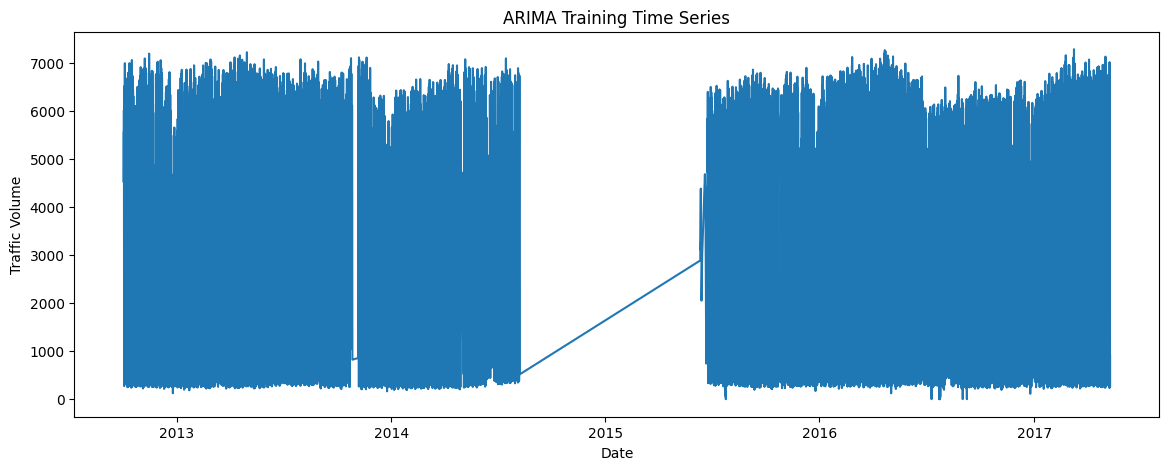

In [137]:
plt.figure(figsize=(14, 5))

plt.plot(arima_train)

plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.title("ARIMA Training Time Series")

plt.show()

## Check stationarity

In [138]:
print("NaN values in arima_train:", arima_train.isna().sum())
print("Infinite values in arima_train:", np.isinf(arima_train).sum())
print("Total observations:", len(arima_train))

NaN values in arima_train: 0
Infinite values in arima_train: 0
Total observations: 40340


In [139]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(arima_train)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is non-stationary.")

ADF Statistic: -14.103397325603991
p-value: 2.594781820997584e-26
The series is stationary.


## Difference the series for visualization

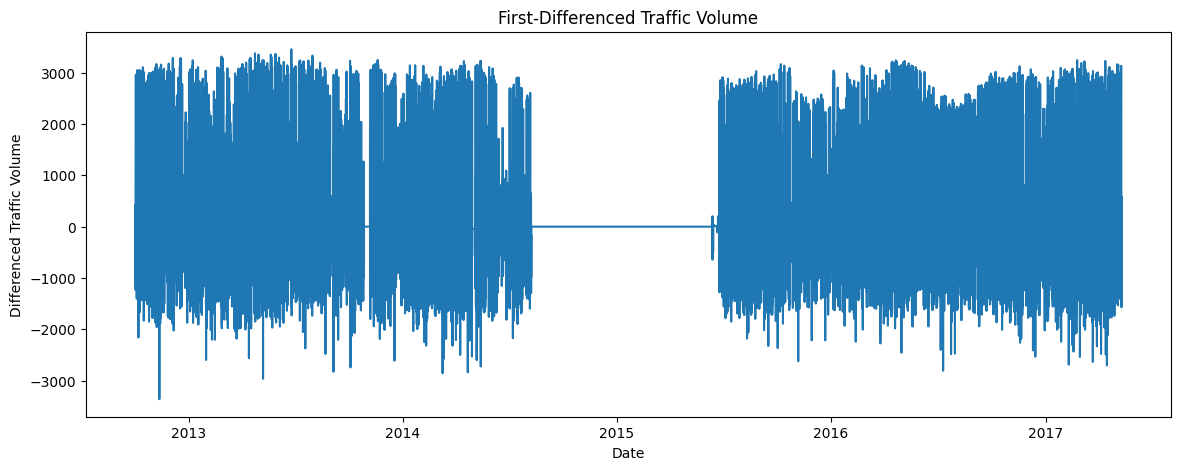

In [140]:
traffic_diff = arima_train.diff().dropna()

plt.figure(figsize=(14, 5))

plt.plot(traffic_diff)

plt.xlabel("Date")
plt.ylabel("Differenced Traffic Volume")
plt.title("First-Differenced Traffic Volume")

plt.show()

## ACF And PACF

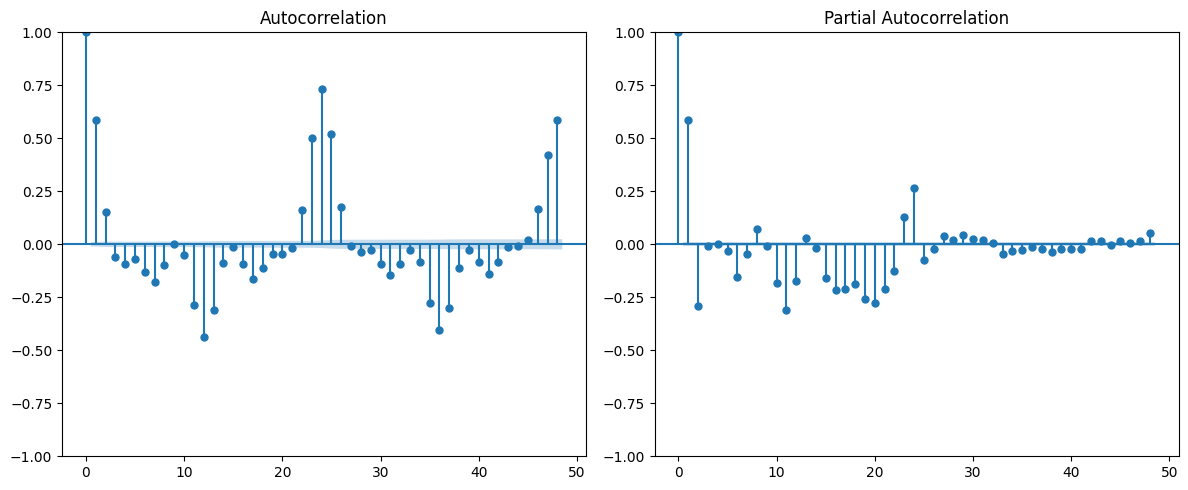

In [141]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig = plt.figure(figsize=(12, 5))

plot_acf(traffic_diff, lags=48, ax=fig.add_subplot(1, 2, 1))
plot_pacf(traffic_diff, lags=48, ax=fig.add_subplot(1, 2, 2))

plt.tight_layout()
plt.show()

In [142]:
ARIMA(arima_train, order=(1,1,1))

## Try multiple ARIMA orders

In [143]:
orders = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

results = []

for order in orders:
    try:
        model = ARIMA(arima_train, order=order)
        model_fit = model.fit()

        results.append({
            'Order': order,
            'AIC': model_fit.aic,
            'BIC': model_fit.bic
        })

        print(f"ARIMA{order} → AIC: {model_fit.aic:.2f}")

    except Exception as e:
        print(f"ARIMA{order} failed:", e)

arima_results = pd.DataFrame(results)

arima_results.sort_values('AIC')

ARIMA(0, 1, 1) → AIC: 627240.83
ARIMA(1, 1, 0) → AIC: 627821.18
ARIMA(1, 1, 1) → AIC: 624901.41
ARIMA(2, 1, 1) → AIC: 624268.96
ARIMA(1, 1, 2) → AIC: 624567.49
ARIMA(2, 1, 2) → AIC: 624261.72


,Order,AIC,BIC
5,"(2, 1, 2)",624261.717406,624304.742776
3,"(2, 1, 1)",624268.957041,624303.377337
4,"(1, 1, 2)",624567.490210,624601.910506
2,"(1, 1, 1)",624901.414813,624927.230035
0,"(0, 1, 1)",627240.825138,627258.035286
1,"(1, 1, 0)",627821.175469,627838.385617


## Select the best order

In [144]:
best_order = arima_results.loc[
    arima_results['AIC'].idxmin(),
    'Order'
]

print("Best ARIMA order:", best_order)

Best ARIMA order: (2, 1, 2)


## Fit the selected model

In [145]:
arima_model = ARIMA(
    arima_train,
    order=best_order
)

arima_model_fit = arima_model.fit()

print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         traffic_volume   No. Observations:                40340
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -312125.859
Date:                Thu, 10 Sep 2026   AIC                         624261.717
Time:                        03:08:31   BIC                         624304.743
Sample:                    10-02-2012   HQIC                        624275.331
                         - 05-10-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6137      0.037     16.623      0.000       0.541       0.686
ar.L2         -0.2636      0.014    -18.664      0.000      -0.291      -0.236
ma.L1          0.1377      0.037      3.725      0.0

## Forecast the validation set

In [146]:
arima_val_pred = arima_model_fit.forecast(
    steps=len(arima_val)
)

arima_val_pred = pd.Series(
    arima_val_pred,
    index=arima_val.index
)

print("Validation predictions:", len(arima_val_pred))

Validation predictions: 6106


## Evaluate validation performance

In [147]:
mae_val_arima = mean_absolute_error(
    arima_val,
    arima_val_pred
)

mse_val_arima = mean_squared_error(
    arima_val,
    arima_val_pred
)

rmse_val_arima = np.sqrt(mse_val_arima)

r2_val_arima = r2_score(
    arima_val,
    arima_val_pred
)

print("ARIMA Validation Performance")
print("-----------------------------")
print(f"MAE  : {mae_val_arima:.2f}")
print(f"MSE  : {mse_val_arima:.2f}")
print(f"RMSE : {rmse_val_arima:.2f}")
print(f"R²   : {r2_val_arima:.4f}")

ARIMA Validation Performance
-----------------------------
MAE  : 2360.26
MSE  : 7885752.56
RMSE : 2808.16
R²   : -1.0397


## Combine train + validation

In [148]:
arima_train_val = pd.concat([
    arima_train,
    arima_val
])

print("Train + Validation observations:",
      len(arima_train_val))

Train + Validation observations: 46446


## Final ARIMA model

In [149]:
final_arima_model = ARIMA(
    arima_train_val,
    order=best_order
)

final_arima_fit = final_arima_model.fit()

print(final_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         traffic_volume   No. Observations:                46446
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -360200.433
Date:                Thu, 10 Sep 2026   AIC                         720410.865
Time:                        03:08:43   BIC                         720454.595
Sample:                    10-02-2012   HQIC                        720424.610
                         - 01-19-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6078      0.034     18.106      0.000       0.542       0.674
ar.L2         -0.2658      0.013    -20.457      0.000      -0.291      -0.240
ma.L1          0.1494      0.034      4.444      0.0

## Forecast the test set

In [150]:
arima_test_pred = final_arima_fit.forecast(
    steps=len(arima_test)
)

arima_test_pred = pd.Series(
    arima_test_pred,
    index=arima_test.index
)

print("Test predictions:", len(arima_test_pred))

Test predictions: 6105


## Final ARIMA performance

In [151]:
mae_arima = mean_absolute_error(
    arima_test,
    arima_test_pred
)

mse_arima = mean_squared_error(
    arima_test,
    arima_test_pred
)

rmse_arima = np.sqrt(mse_arima)

r2_arima = r2_score(
    arima_test,
    arima_test_pred
)

print("ARIMA Test Performance")
print("-------------------------")
print(f"MAE  : {mae_arima:.2f}")
print(f"MSE  : {mse_arima:.2f}")
print(f"RMSE : {rmse_arima:.2f}")
print(f"R²   : {r2_arima:.4f}")

ARIMA Test Performance
-------------------------
MAE  : 2388.49
MSE  : 8924468.90
RMSE : 2987.38
R²   : -1.2751


## Actual vs predicted

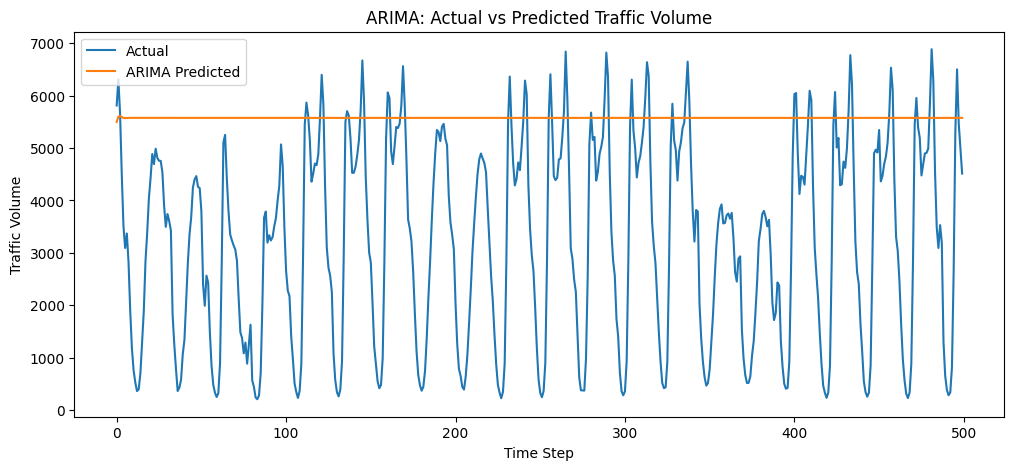

In [152]:
plt.figure(figsize=(12, 5))

plt.plot(
    arima_test.values[:500],
    label='Actual'
)

plt.plot(
    arima_test_pred.values[:500],
    label='ARIMA Predicted'
)

plt.xlabel('Time Step')
plt.ylabel('Traffic Volume')
plt.title('ARIMA: Actual vs Predicted Traffic Volume')

plt.legend()
plt.show()

## Scatter plot

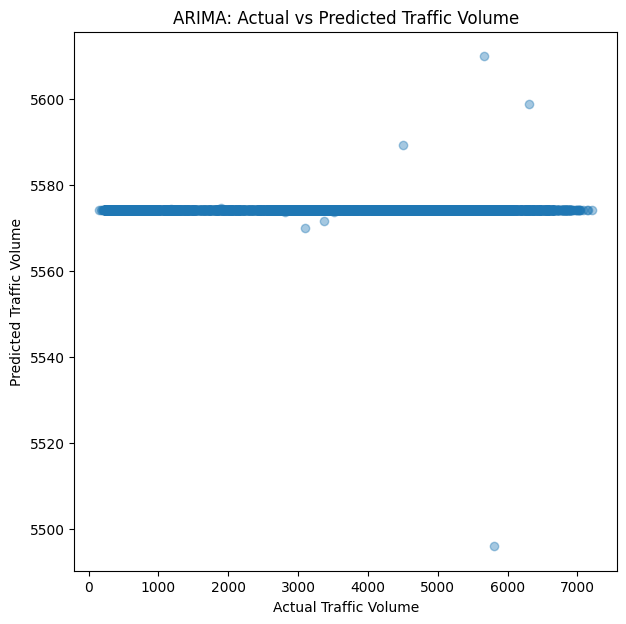

In [153]:
plt.figure(figsize=(7, 7))

plt.scatter(
    arima_test,
    arima_test_pred,
    alpha=0.4
)

plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('ARIMA: Actual vs Predicted Traffic Volume')

plt.show()

# Build LSTM Model

In [154]:
X_train_lstm, y_train_lstm = create_sequences(
    train_scaled_df,
    features,
    target,
    sequence_length=24
)

In [155]:
X_val_lstm, y_val_lstm = create_sequences(
    val_scaled_df,
    features,
    target,
    sequence_length=24
)

In [156]:
X_test_lstm, y_test_lstm = create_sequences(
    test_scaled_df,
    features,
    target,
    sequence_length=24
)

In [157]:
print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)

print("X_val_lstm:", X_val_lstm.shape)
print("y_val_lstm:", y_val_lstm.shape)

print("X_test_lstm:", X_test_lstm.shape)
print("y_test_lstm:", y_test_lstm.shape)

X_train_lstm: (17251, 24, 22)
y_train_lstm: (17251,)
X_val_lstm: (5771, 24, 22)
y_val_lstm: (5771,)
X_test_lstm: (5801, 24, 22)
y_test_lstm: (5801,)


In [158]:
print("First sequence shape:", X_train_lstm[0].shape)

First sequence shape: (24, 22)


In [159]:
print("First sequence:")
print(X_train_lstm[0])

First sequence:
[[0.9526992  0.         0.         0.2        0.7826087  0.06666667
  0.33333333 0.81818182 0.         0.         0.         0.
  1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.94293408 0.         0.         0.2        0.82608696 0.06666667
  0.33333333 0.81818182 0.         0.         0.         0.
  1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.93495328 0.         0.         0.2        0.86956522 0.06666667
  0.33333333 0.81818182 0.         0.         0.         0.
  1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.93141708 0.         0.         0.01       0.91304348 0.06666667
  0.33333333 0.81818182 0.         0.         0.         1.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.92865949 0.         0.         0.01     

In [160]:
print("Target:")
print(y_train_lstm[0])

Target:
0.6740384615384616


# ANN

In [161]:
X_train_ann = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    -1
)

X_val_ann = X_val_lstm.reshape(
    X_val_lstm.shape[0],
    -1
)

X_test_ann = X_test_lstm.reshape(
    X_test_lstm.shape[0],
    -1
)

In [162]:
print("X_train_ann:", X_train_ann.shape)
print("X_val_ann:", X_val_ann.shape)
print("X_test_ann:", X_test_ann.shape)

X_train_ann: (17251, 528)
X_val_ann: (5771, 528)
X_test_ann: (5801, 528)


In [163]:
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(528,)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

In [164]:
ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [165]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        67,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

In [166]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [167]:
history_ann = ann_model.fit(
    X_train_ann,
    y_train_lstm,
    validation_data=(X_val_ann, y_val_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0248 - mae: 0.1180 - val_loss: 0.0131 - val_mae: 0.0860
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0099 - mae: 0.0733 - val_loss: 0.0104 - val_mae: 0.0786
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0077 - mae: 0.0638 - val_loss: 0.0103 - val_mae: 0.0786
Epoch 4/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0068 - mae: 0.0592 - val_loss: 0.0109 - val_mae: 0.0820
Epoch 5/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0062 - mae: 0.0564 - val_loss: 0.0101 - val_mae: 0.0776
Epoch 6/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0058 - mae: 0.0542 - val_loss: 0.0086 - val_mae: 0.0716
Epoch 7/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0055 - mae: 0.0525 - val_loss: 0.0102 - val_mae: 0.0785
Epoch 8/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0053 - mae: 0.0518 - val_loss: 0.0070 - val_mae: 0.0641
Epoch 9/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/

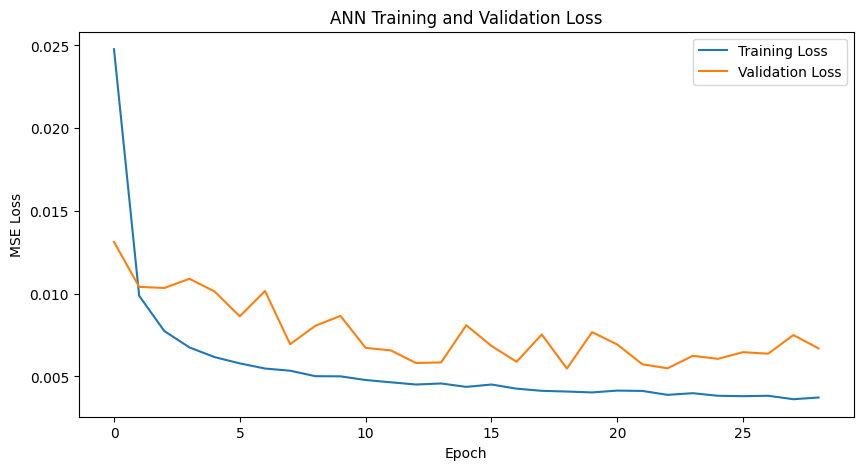

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_ann.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_ann.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training and Validation Loss')

plt.legend()
plt.show()

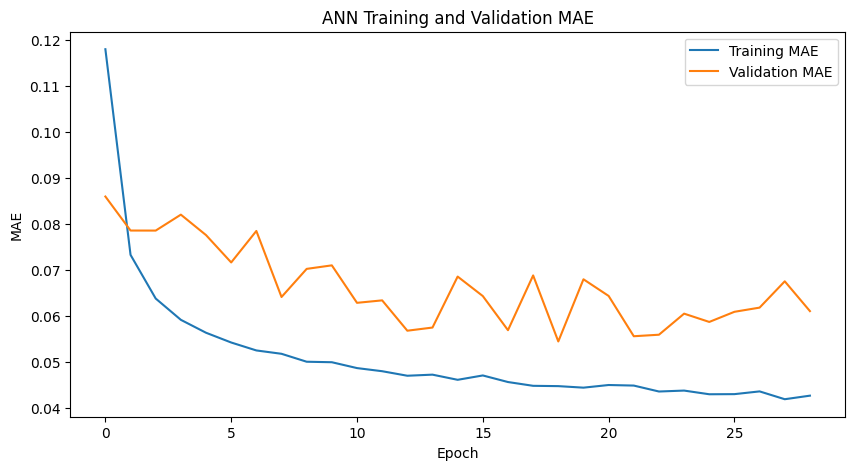

In [169]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_ann.history['mae'],
    label='Training MAE'
)

plt.plot(
    history_ann.history['val_mae'],
    label='Validation MAE'
)

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('ANN Training and Validation MAE')

plt.legend()
plt.show()

In [170]:
y_pred_scaled = ann_model.predict(X_test_ann)

print("Prediction shape:", y_pred_scaled.shape)

182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Prediction shape: (5801, 1)


In [171]:
y_pred = target_scaler.inverse_transform(y_pred_scaled).ravel()

y_actual = target_scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
).ravel()

In [172]:
print("First 10 actual values:")
print(y_actual[:10])

print("\nFirst 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
[4811. 4757. 4754. 4530. 3900. 3497. 3742. 3608. 3427. 1830.]

First 10 predicted values:
[4635.8735  4679.7983  4537.7563  4284.574   3257.1802  3295.4268
 3011.5315  2761.6418  2046.9155   882.59937]


In [173]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_actual, y_pred)

mse = mean_squared_error(y_actual, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_actual, y_pred)

print("ANN Performance")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

ANN Performance
-------------------------
MAE  : 336.91
MSE  : 223858.12
RMSE : 473.14
R²   : 0.9430


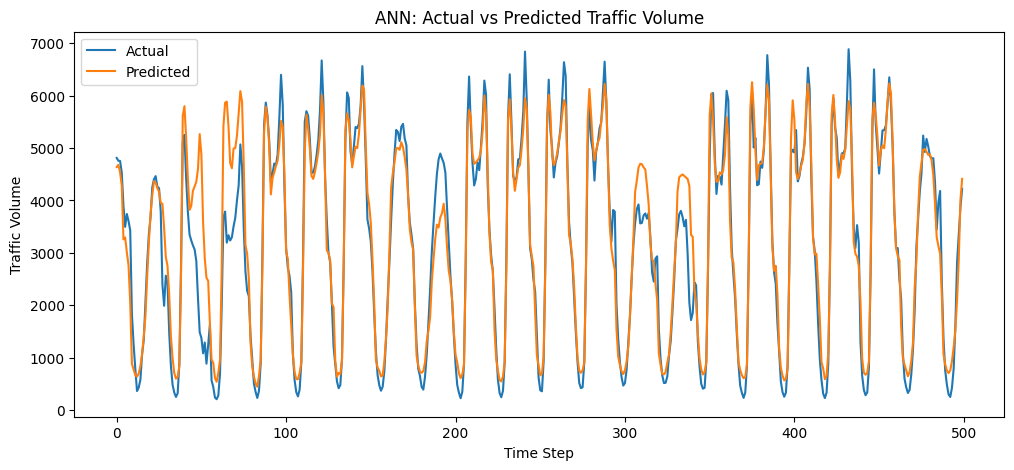

In [174]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_actual[:500],
    label='Actual'
)

plt.plot(
    y_pred[:500],
    label='Predicted'
)

plt.xlabel('Time Step')
plt.ylabel('Traffic Volume')
plt.title('ANN: Actual vs Predicted Traffic Volume')

plt.legend()
plt.show()

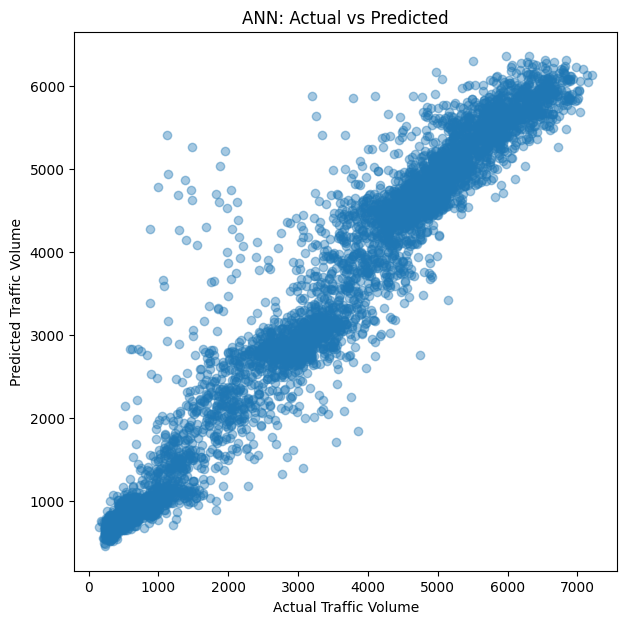

In [175]:
plt.figure(figsize=(7, 7))

plt.scatter(y_actual, y_pred, alpha=0.4)

plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('ANN: Actual vs Predicted')

plt.show()

# LSTM Model

In [176]:
lstm_model = Sequential([
    LSTM(64, input_shape=(24, 22)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

In [177]:
lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [178]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

In [179]:
early_stopping_lstm = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [180]:
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_lstm],
    verbose=1
)

Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0267 - mae: 0.1196 - val_loss: 0.0084 - val_mae: 0.0670
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0079 - mae: 0.0642 - val_loss: 0.0062 - val_mae: 0.0537
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0065 - mae: 0.0566 - val_loss: 0.0056 - val_mae: 0.0515
Epoch 4/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0056 - mae: 0.0529 - val_loss: 0.0059 - val_mae: 0.0552
Epoch 5/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0053 - mae: 0.0512 - val_loss: 0.0059 - val_mae: 0.0553
Epoch 6/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0051 - mae: 0.0495 - val_loss: 0.0059 - val_mae: 0.0556
Epoch 7/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0049 - mae: 0.0486 - val_loss: 0.0057 - val_mae: 0.0545
Epoch 8/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0047 - mae: 0.0471 - val_loss: 0.0077 - val_mae: 0.0657
Epoch 9/100
540/540 ━━━━━━━━━━━━━━━

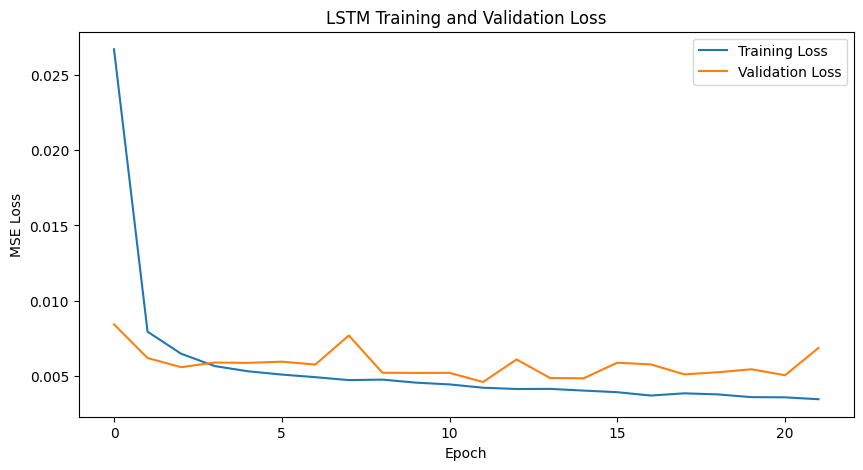

In [181]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.show()

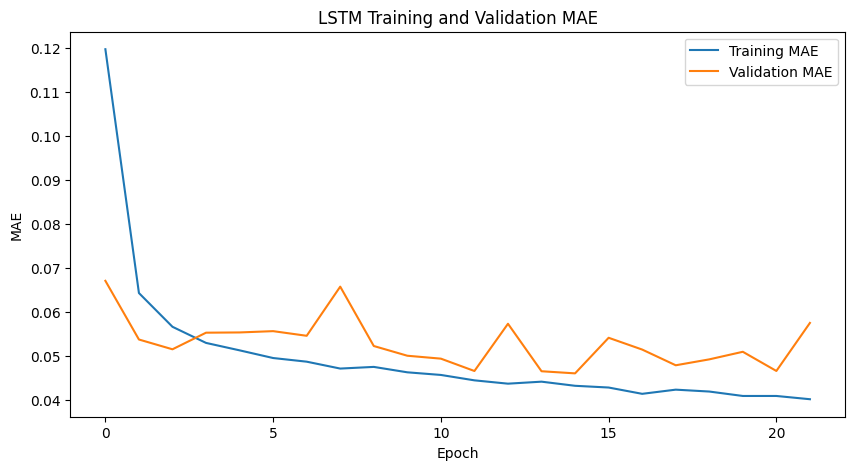

In [182]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm.history['mae'],
    label='Training MAE'
)

plt.plot(
    history_lstm.history['val_mae'],
    label='Validation MAE'
)

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('LSTM Training and Validation MAE')
plt.legend()
plt.show()

In [183]:
y_pred_scaled_lstm = lstm_model.predict(X_test_lstm)

182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [184]:
y_pred_lstm = target_scaler.inverse_transform(
    y_pred_scaled_lstm
).ravel()

y_actual_lstm = target_scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
).ravel()

In [185]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_actual_lstm, y_pred_lstm)

mse = mean_squared_error(y_actual_lstm, y_pred_lstm)

rmse = np.sqrt(mse)

r2 = r2_score(y_actual_lstm, y_pred_lstm)

print("LSTM Performance")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

LSTM Performance
-------------------------
MAE  : 327.58
MSE  : 231837.65
RMSE : 481.50
R²   : 0.9409


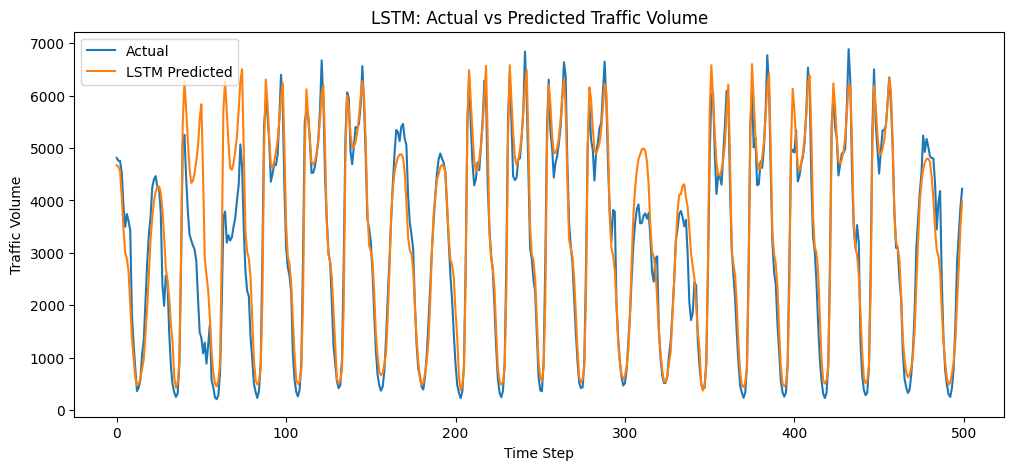

In [186]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_actual_lstm[:500],
    label='Actual'
)

plt.plot(
    y_pred_lstm[:500],
    label='LSTM Predicted'
)

plt.xlabel('Time Step')
plt.ylabel('Traffic Volume')
plt.title('LSTM: Actual vs Predicted Traffic Volume')

plt.legend()
plt.show()

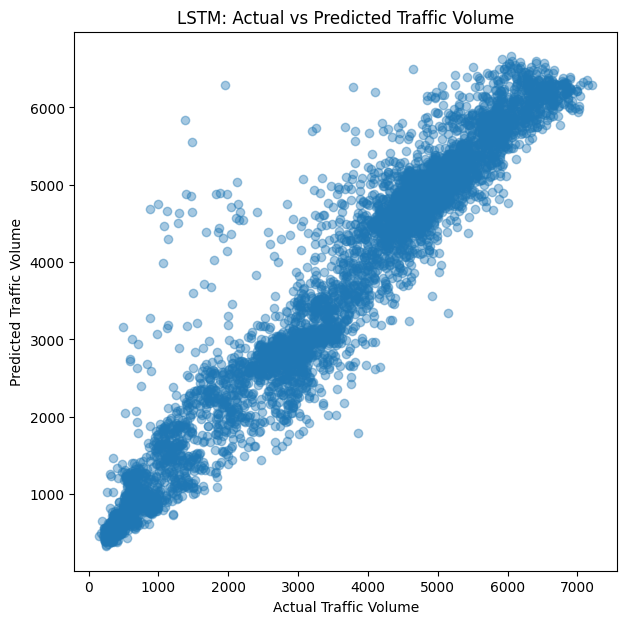

In [187]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_actual_lstm,
    y_pred_lstm,
    alpha=0.4
)

plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('LSTM: Actual vs Predicted Traffic Volume')

plt.show()

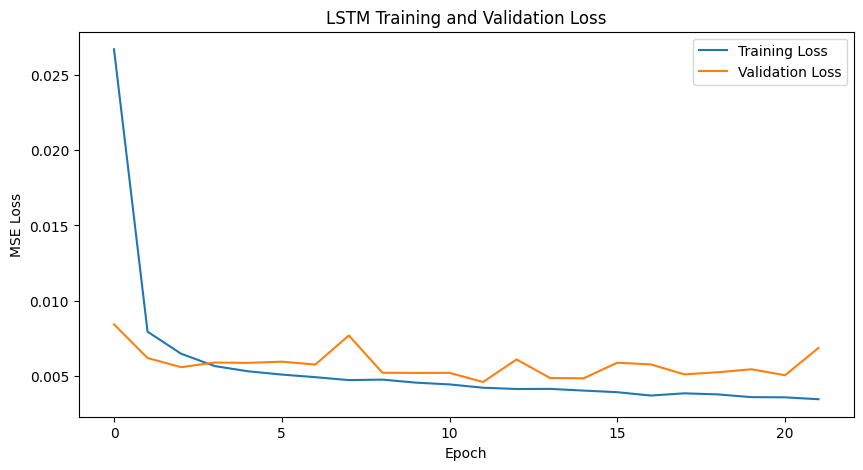

In [188]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training and Validation Loss')

plt.legend()
plt.show()

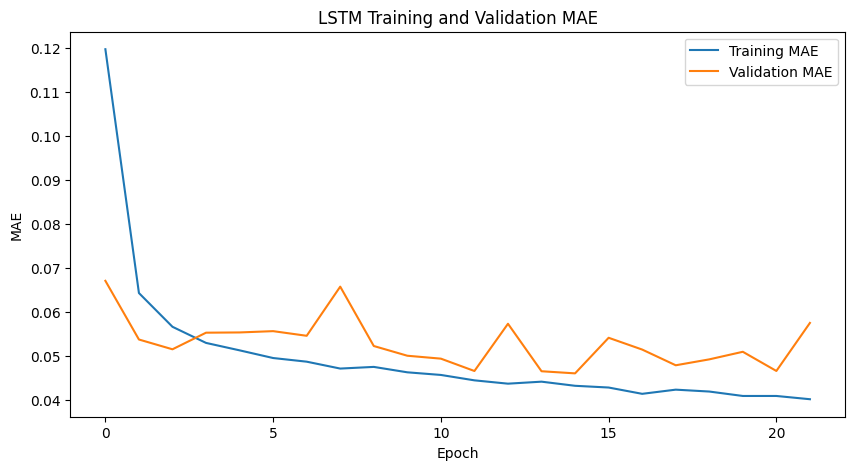

In [189]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm.history['mae'],
    label='Training MAE'
)

plt.plot(
    history_lstm.history['val_mae'],
    label='Validation MAE'
)

plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.title('LSTM Training and Validation MAE')

plt.legend()
plt.show()

In [190]:
import joblib

# Save the trained LSTM model
lstm_model.save("traffic_lstm_model.keras")

# Save the feature scaler
joblib.dump(feature_scaler, "traffic_feature_scaler.pkl")

# Save the target scaler
joblib.dump(target_scaler, "traffic_target_scaler.pkl")

print("LSTM model and scalers saved successfully!")

LSTM model and scalers saved successfully!


In [191]:
import os

print(os.listdir())

['.config', 'traffic_feature_scaler.pkl', 'smart_traffic_ml_cleaned.csv', 'traffic_target_scaler.pkl', 'traffic_lstm_model.keras', 'sample_data']


In [192]:
# from google.colab import files

# files.download("traffic_lstm_model.keras")

In [193]:
# files.download("traffic_feature_scaler.pkl")

In [194]:
# files.download("traffic_target_scaler.pkl")